In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
from src.models import LinearRegression
from src.utils import load_data
from src.preprocessing import area_units_conversion

In [17]:
dir_base = "data/processed/"
train_path = dir_base + "casas_train_filled.csv"
validation_path = dir_base + "casas_val_filled.csv"
test_path = dir_base + "casas_test_filled.csv"

already_scaled = False

def use_test(test_path, is_scaled=False, train_stats=None):
    test = pd.read_csv(test_path)
    test = area_units_conversion(test)
    # if is_scaled:
    #    test = scale_df(test, train_stats, True)
       
    return test

test = use_test(test_path)

features = ["area", "is_house", "has_pool", "age", "lat", "lon", "rooms"] 
target = "price"

X_train, y_train = load_data(train_path, None, features, target)
X_val, y_val = load_data(validation_path, None, features, target)
X_test, y_test = load_data("", test, features, target, True)


In [18]:
X_train_1 = X_train[:, [0]]  # Solo area
X_val_1 = X_val[:, [0]]  
X_test_1 = X_test[:, [0]]

Error cuadrático medio (MSE) en test: 84953.1090


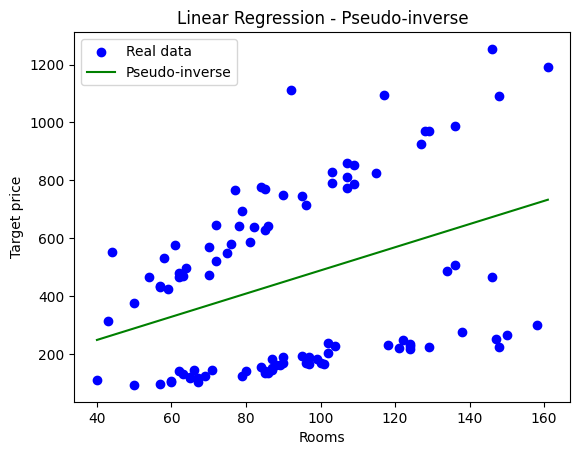

In [19]:
modelo = LinearRegression(X_train_1, y_train, X_val_1, y_val, ["area"])
modelo.entrenar_pseudoinversa()
modelo.evaluar(X_test_1, y_test)
modelo.graficar_regresion_pseudoinversa(X_test_1, y_test, ["Rooms"])


In [20]:
model_multi_pinv = LinearRegression(X_train, y_train, X_val, y_val, features)
model_multi_pinv.entrenar_pseudoinversa()
model_multi_pinv.evaluar(X_test, y_test)

Error cuadrático medio (MSE) en test: 12373.5585


12373.558474124568

In [21]:
coeficientes = model_multi_pinv.coef
coef_dict = dict(zip(["intercept"] + features, coeficientes))
print(f"Coeficiente de has_pool: {coef_dict['has_pool']:.2f}")



Coeficiente de has_pool: 0.02


In [22]:
price_min = model_multi_pinv.stats["price"]["min"]
price_max = model_multi_pinv.stats["price"]["max"]

impacto_real = 0.02 * (price_max - price_min)
print(f"Impacto estimado en unidades monetarias: {impacto_real:.2f}")

Impacto estimado en unidades monetarias: 38.54


$\Delta \text{precio real} = 0.02 × (\text{precio máximo} − \text{precio mínimo})$

In [23]:
# modelo = LinearRegression(X_train_1, y_train, X_val_1, y_val, [""])
# modelo.entrenar_pseudoinversa()
# modelo.evaluar(X_test_1, y_test)
# modelo.graficar_regresion_pseudoinversa(X_test_1, y_test, ["Area"])

In [24]:
relevant_features = ["area", "has_pool", "lat", "lon", "rooms"] 

feature_indices = {feature: idx for idx, feature in enumerate(features)}
selected_indices = [feature_indices[f] for f in relevant_features]

X_train_subset = X_train[:, selected_indices]
X_val_subset = X_val[:, selected_indices]
X_test_subset = X_test[:, selected_indices]

In [25]:
model_selected_features_pinv = LinearRegression(X_train_subset, y_train, X_val_subset, y_val, relevant_features)
model_selected_features_pinv.entrenar_pseudoinversa()
model_selected_features_pinv.evaluar(X_test_subset, y_test)

Error cuadrático medio (MSE) en test: 11941.4692


11941.469154463524

In [ ]:
import numpy as np
import pandas as pd

train_path = dir_base + "casas_train_filled.csv"
validation_path = dir_base + "casas_val_filled.csv"
test_path = dir_base + "casas_test_filled.csv"

casas_train_df = pd.read_csv(train_path)
casas_val_df = pd.read_csv(validation_path)
casas_test_df = pd.read_csv(test_path)

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Radio de la Tierra en km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

def dbscan(coords, eps=0.5, min_pts=5):
    labels = np.full(len(coords), -1)  # Inicializar con -1 (ruido)
    cluster_id = 0
    
    def region_query(point_idx):
        neighbors = []
        for i, point in enumerate(coords):
            if haversine(*coords[point_idx], *point) <= eps:
                neighbors.append(i)
        return neighbors
    
    def expand_cluster(point_idx, neighbors):
        labels[point_idx] = cluster_id
        i = 0
        while i < len(neighbors):
            n_idx = neighbors[i]
            if labels[n_idx] == -1:  # Si era ruido, ahora es parte del cluster
                labels[n_idx] = cluster_id
            if labels[n_idx] == -1:
                labels[n_idx] = cluster_id
                new_neighbors = region_query(n_idx)
                if len(new_neighbors) >= min_pts:
                    neighbors += new_neighbors
            i += 1
    
    for i in range(len(coords)):
        if labels[i] != -1:
            continue
        neighbors = region_query(i)
        if len(neighbors) < min_pts:
            labels[i] = -1  # Sigue siendo ruido
        else:
            expand_cluster(i, neighbors)
            cluster_id += 1
    
    return labels

lat_lon_train = casas_train_df[['lat', 'lon']].values
lat_lon_val = casas_val_df[['lat', 'lon']].values
lat_lon_test = casas_test_df[['lat', 'lon']].values

# Entrenar DBSCAN sobre train
train_labels = dbscan(lat_lon_train, eps=0.5, min_pts=2)

# Asignar clusters a val y test usando los centroides de train
centroids = {label: np.mean(lat_lon_train[train_labels == label], axis=0) for label in set(train_labels) if label != -1}

def assign_to_cluster(point):
    min_dist = float('inf')
    best_cluster = -1
    for cluster_id, centroid in centroids.items():
        dist = haversine(*point, *centroid)
        if dist < min_dist:
            min_dist = dist
            best_cluster = cluster_id
    return best_cluster

val_labels = np.array([assign_to_cluster(p) for p in lat_lon_val])
test_labels = np.array([assign_to_cluster(p) for p in lat_lon_test])

# Agregar etiquetas de cluster a los datasets
casas_train_df['cluster_id'] = train_labels
casas_val_df['cluster_id'] = val_labels
casas_test_df['cluster_id'] = test_labels

num_clusters = len(set(train_labels)) - (1 if -1 in train_labels else 0)
print(f"Número de clusters encontrados: {num_clusters}")

clusters_unicos = set(train_labels)
print(f"Clusters únicos: {clusters_unicos}")

# Crear un diccionario para almacenar la distancia de cada punto a su centroide
train_distances = np.array([
    haversine(*lat_lon_train[i], *centroids[train_labels[i]]) if train_labels[i] != -1 else np.nan
    for i in range(len(lat_lon_train))
])

val_distances = np.array([
    haversine(*lat_lon_val[i], *centroids[val_labels[i]]) if val_labels[i] != -1 else np.nan
    for i in range(len(lat_lon_val))
])

test_distances = np.array([
    haversine(*lat_lon_test[i], *centroids[test_labels[i]]) if test_labels[i] != -1 else np.nan
    for i in range(len(lat_lon_test))
])

# Agregar las distancias como una nueva columna en los datasets
casas_train_df['dist_to_cluster_centroid'] = train_distances
casas_val_df['dist_to_cluster_centroid'] = val_distances
casas_test_df['dist_to_cluster_centroid'] = test_distances

train_clusters_summary = casas_train_df.groupby("cluster_id")['dist_to_cluster_centroid'].agg(['count', 'mean'])
print(train_clusters_summary)


import matplotlib.pyplot as plt

plt.hist(casas_train_df['dist_to_cluster_centroid'].dropna(), bins=30, edgecolor='black')
plt.xlabel("Distancia al centroide del cluster (km)")
plt.ylabel("Cantidad de propiedades")
plt.title("Distribución de distancias al centroide")
plt.show()



In [27]:
from geopy.geocoders import Nominatim
import pandas as pd

In [28]:


# Crear geolocalizador
# geolocator = Nominatim(user_agent="geoapiExercises")
geolocator = Nominatim(user_agent="geoapi")

# Función para obtener la dirección
def get_address(lat, lon):
    location = geolocator.reverse((lat, lon), language='es', timeout=10)
    return location.address if location else None

# Agregar la nueva columna con la dirección al dataset
casas_train_df['direccion'] = casas_train_df.apply(lambda row: get_address(row['lat'], row['lon']), axis=1)
casas_val_df['direccion'] = casas_val_df.apply(lambda row: get_address(row['lat'], row['lon']), axis=1)
casas_test_df['direccion'] = casas_test_df.apply(lambda row: get_address(row['lat'], row['lon']), axis=1)

# Mostrar los primeros resultados
print(casas_train_df[['lat', 'lon', 'direccion']].head())
print(casas_val_df[['lat', 'lon', 'direccion']].head())
print(casas_test_df[['lat', 'lon', 'direccion']].head())


         lat        lon                                          direccion
0  40.718433 -74.008699  Worth Street, Tribeca, Manhattan, Condado de N...
1  40.707037 -73.998823  Brooklyn Bridge, South Street, Two Bridges, Ci...
2 -34.550223 -58.391268                                          Argentina
3  40.726223 -74.043929  121, 7th Street, Hamilton Park, Ciudad de Jers...
4 -34.563525 -58.347365                                          Argentina
         lat        lon                                          direccion
0 -34.594131 -58.376226  1239, Avenida Crucero Belgrano, Retiro, Buenos...
1 -34.666449 -58.359236  Arenales, Barrio Güemes, Crucecita, Avellaneda...
2 -34.621948 -58.387620  Colegio 01 Bernardino Rivadavia, Avenida San J...
3  40.717292 -74.023431  Battery Park City Greenway, Battery Park City,...
4 -34.588929 -58.355961                                          Argentina
         lat        lon                                          direccion
0 -34.605351 -58.406746  

In [29]:
def save_csv(df, nombre_archivo):
    """Guarda un DataFrame en un archivo CSV."""
    df.to_csv(nombre_archivo, index=False)
    print(f"Dataset guardado como '{nombre_archivo}'.")
    
save_csv(casas_train_df, "data/processed/casas_train_geocoded.csv")
save_csv(casas_val_df, "data/processed/casas_val_geocoded.csv") 
save_csv(casas_test_df, "data/processed/casas_test_geocoded.csv")

Dataset guardado como 'data/processed/casas_train_geocoded.csv'.
Dataset guardado como 'data/processed/casas_val_geocoded.csv'.
Dataset guardado como 'data/processed/casas_test_geocoded.csv'.
